In [1]:
import os
import random
import time

import numpy as np
import scipy as sp
import pandas as pd

from sklearn.model_selection import ParameterGrid

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

from IPython.display import display, Audio

In [2]:
%load_ext line_profiler
%load_ext autoreload
%autoreload 2

In [ ]:
# Change error handling for numpy
#np.seterr(all='raise', under='ignore')

In [3]:
from source_generation import compute_attenuation, combine_sources, load_wav_files, display_results
from duet_ms import DuetMS

In [ ]:
base_dir = "FOAMS_processed_audio"

# load segmentation_info and create a dictionary
seg_info = pd.read_csv("segmentation_info.csv")
seg_dict = dict(zip(seg_info['id'], seg_info['label']))
all_sources = load_wav_files(base_dir)

In [ ]:
# Setup parameter grid to search

grid = {
    # Audio Lengths to try (in ms)
    # Original target was 96ms, must be multiple of 16ms
    # In theory, longer audio lengths should give better results, but take longer to compute and use more memory
    "audio_length": [64, 80, 96],  # TODO: add 112

    # STFT window sizes to try
    # Must be power of 2, larger windows give better frequency resolution but worse time resolution
    "window": [128, 256],  # TODO: try [64, 128, 256, 512, 1024]

    # Oversampling factors to try
    # Must be odd integers with 1 being no oversampling
    # Higher oversampling improves resolution in STFT but is much slower
    "oversample": [1, 3],  # [1, 3, 5],  # higher is much, much, slower and not typically better

    # Thresholds to try for peak picking
    # Lower thresholds include more data but may include more noise and will be slower
    "threshold": [0.25, 0.35, 0.5, 0.75],  # [0.05, 0.1, 0.2, 0.25, 0.5, 0.75]

    # Bandwidths to try for mean-shift
    # Single values are isotropic, tuples are (time_bandwidth, frequency_bandwidth)
    # Bandwidths that are too small may lead to overfitting/noise, too large may miss sources
    # This is one of the most important parameters to tune and is likely anisotropic
    # This also effects grid size and thus memory usage and speed
    "bandwidth": [
        0.1, 0.2, 0.25, 0.3, 0.4,
        (0.1, 0.2), (0.1, 0.25), (0.1, 0.3), (0.1, 0.4),
        (0.2, 0.1), (0.2, 0.25), (0.2, 0.3), (0.2, 0.4),
        (0.25, 0.1), (0.25, 0.2), (0.25, 0.3), (0.25, 0.4),
        (0.3, 0.1), (0.3, 0.2), (0.3, 0.25), (0.3, 0.4),
        (0.4, 0.1), (0.4, 0.2), (0.4, 0.25), (0.4, 0.3),
    ],

    # Alpha max values to try, hardcoded for now
    "alpha_max": [1.5],  # TODO:
    # Delta max values to try, hardcoded for now
    "delta_max": [8.5],  # TODO:

    # Seed counts to try for mean-shift initialization
    # More seeds means that more unique peaks can possible be found (which may or may not be noise), but is slower
    # None means to use all possible unique peaks
    "seed_count": [20, 25, 35],            # [10, 25, 50, 75, 100] # None is slow and bad

    # Minimum bin counts to try for mean-shift seed selection
    # Larger will eliminate more seeds and be faster, but may miss some sources (but also may eliminate noise peaks)
    # A value of 1 means no elimination
    "min_bin_count": [5, 10],              # [1, 5, 10, 25, 50, 100]  # in general, larger is much worse and only slightly faster (but there are others that are just as fast)

    # Convergence tolerances to try for mean-shift
    # Larger tolerances will converge faster but may be less accurate
    # A value of 1.0 means it will converge once reaching the nearest grid point
    "convergence_tol": [0.2, 0.25, 0.3],   # [0.05, 0.1, 0.2, 0.25, 0.5]

    # Alpha conversion operations to try
    # "symmetric" is the original DUET operation, "log" is a logarithmic scaling
    # "none" is not recommended as it makes no sense
    "alpha_op": ["symmetric", "log"],

    # Big delay methods to try
    # "none" is the original DUET method (will not work in our system)
    # "diff" is a differential method
    "big_delay": ["diff"],

    # Delta smoothing parameters to try
    # Smoothing helps reduce noise in delta estimates and is especially important for big-delta
    # Tuples are (freq, time) smoothing kernel sizes; (1, 1) means no smoothing
    "delta_smoothing": [(3, 1), (3, 3), (5, 1), (5, 3)],  # (1, 1), (3, 1), (3, 3), (5, 1), (5, 3)

    # Delta smoothing modes to try
    # Can be "mean", "median", or "gaussian"
    "delta_smoothing_mode": ["mean", "median", "gaussian"],
}
param_grid = ParameterGrid(grid)

print(np.prod([len(v) for v in grid.values()]))

518400


In [ ]:

# Generate test audio data

# Number of sources to mix into each sample
num_sources = 2

# Number of samples to generate
num_samples = 10

# Random number generator to use for reproducibility
rand = random.Random(42)

# Generate data
data = []
for _ in range(num_samples):
    # Select random sources
    sources = rand.sample(all_sources, num_sources)
    selected_files = [s[0] for s in sources]
    sources = [s[1] for s in sources]

    # Create test delays/attenuations
    delays = [rand.uniform(-8, 8) for _ in sources]
    sym_attens = [rand.uniform(-1, 1) for _ in sources]  # symmetric attenuations between -1 and 1
    attenuations = [compute_attenuation(a) for a in sym_attens]  # compute actual attenuations

    # Generate stereo channels
    audio = combine_sources(sources, delays, attenuations)

    data.append((audio, attenuations, delays))


In [ ]:
def find_alpha_deltas(x: np.ndarray, fs: int = 16000, **params):
    """
    Find alpha and delta peaks for given audio and DUET parameters.
    """
    # Extract audio length and trim audio
    # TODO: does this work?
    audio_length = params.pop("audio_length")
    x = x[:audio_length*fs//1000]

    # Initialize DUET and compute peaks
    duet = DuetMS(fs, **params)
    xx = duet._normalize_data(x)
    _, tf_weights, alpha, delta = duet._compute_all(xx)
    alpha_peaks, delta_peaks = duet._find_peaks(tf_weights, alpha, delta)
    alpha_peaks = duet._convert_alpha_to_atn(alpha_peaks)

    # Return results
    return alpha_peaks, delta_peaks

def rmse(val):
    """
    Compute root mean square error of given values.
    """
    return np.sqrt(np.mean(np.multiply(val, val)))

def score_alpha_deltas(true, pred):
    """
    Score predicted alpha and delta values against true values.
    """
    true = np.transpose(true)
    pred = np.transpose(pred)
    if len(true) == 0 or len(pred) == 0:
        return float('inf')
    dists = sp.spatial.distance_matrix(true, pred)

    # TODO: try other scoring methods
    return (rmse(dists.min(1)) + rmse(dists.min(0))) * (0.01 * np.exp(len(pred) - 5*len(true)) + 1)  # as we get 5 times more predictions than true sources, we start penalizing majorly
    # min1 = dists.min(1)
    # min0 = dists.min(0)
    # return rmse(min1) + rmse(min0) + max(min1.max(), min0.max())

def check_params(params: dict) -> tuple[float, float]:
    """
    Check a given set of DUET parameters by scoring them on the entire test data.

    Returns the overall RMSE score and the average time taken per sample.
    """
    # overall scoring: RMSE of all individual scores
    # individual scores: addition of:
    #    take RMSE of L2 distances between every predicted value and the closest true value - makes sure that every prediction is close to a true source
    #    take RMSE of L2 distances between every true value and the closest predicted value - makes sure that every true source is close to a prediction
    # TODO: problems are though that:
    #    it favors many more predictions than true sources because they average out the bad ones
    #    it doesn't penalize far away predictions as much as it should if there are enough close ones
    #    even the best solutions can be missing some of the true sources
    # maybe use some other form of mean? double count max?
    start = time.time()
    preds = [find_alpha_deltas(d[0], **params) for d in data]
    elapsed = (time.time() - start) / len(data)
    cur_scores = [score_alpha_deltas(d[1:], pred) for d, pred in zip(data, preds)]
    return rmse(cur_scores), elapsed

def display_params(d, params: dict, fs: int = 16000):
    """
    Display results for given data and DUET parameters.
    """
    x = d[0]
    audio_length = params.pop("audio_length")
    x = x[:audio_length*fs//1000]
    duet = DuetMS(fs, **params)
    xx = duet._normalize_data(x)
    _, tf_weights, alpha, delta = duet._compute_all(xx)
    alpha_peaks, delta_peaks = duet._find_peaks(tf_weights, alpha, delta)
    alpha_real = duet._convert_atn_to_alpha(np.array(d[1]))
    delta_real = d[2]
    display_results(alpha, delta, tf_weights, alpha_peaks, delta_peaks, alpha_real, delta_real)
    return score_alpha_deltas((alpha_real, delta_real), (alpha_peaks, delta_peaks))


In [ ]:
# Run parameter search
# Prints progress every 100 evaluations with estimated remaining time and best score so far
scores = []
times = []
overall_start = time.time()

for i, params in enumerate(param_grid):
    if i % 100 == 0 and i > 0:
        elapsed = time.time() - overall_start
        perc = i / len(param_grid)
        per = elapsed / i
        print(f"Evaluating {i}/{len(param_grid)} {perc:.1%}; {per:.2f}s per eval; est remaining {per*(len(param_grid)-i)/60:.1f} min; best so far: {min(scores):.2f}")
    score, elapsed = check_params(params)
    scores.append(score)
    times.append(elapsed)


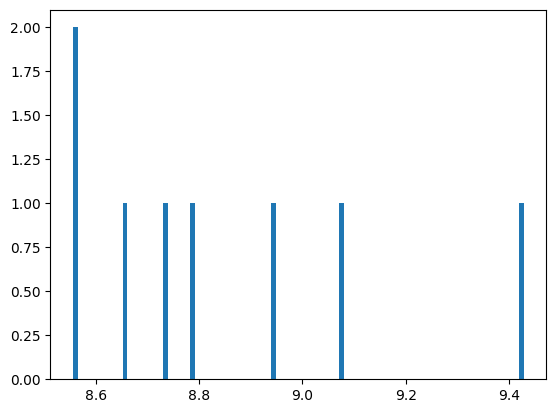

In [ ]:
# Plot overall distribution of scores (lower is better)
plt.hist(scores, bins=100);

Text(0, 0.5, 'Time (s)')

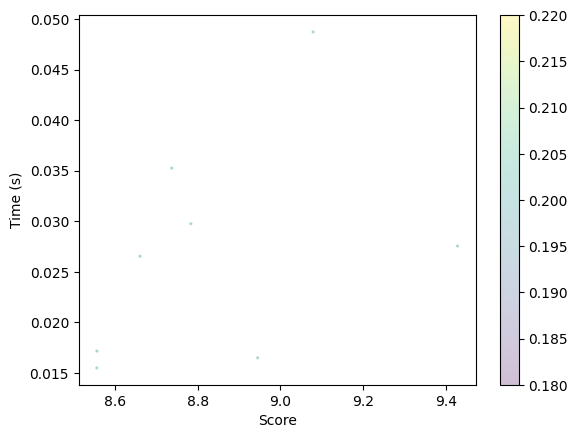

In [27]:
plt.scatter(scores, times, alpha=0.25, s=2, c=[x["convergence_tol"] for x in param_grid])
plt.colorbar()
plt.xlabel("Score")
plt.ylabel("Time (s)")

In [ ]:
# Print out the worst parameter sets
# Is there a pattern? if so, remove those parameters from the grid
bad = np.where(np.array(scores) >= 2.7)[0]
for i in bad:
    print(times[i], scores[i], param_grid[i])
len(bad)

{'window': 128, 'threshold': 0.25, 'seed_count': 20, 'oversample': 1, 'min_bin_count': 5, 'delta_smoothing_mode': 'mean', 'delta_smoothing': (3, 1), 'delta_max': 8.5, 'convergence_tol': 0.2, 'big_delay': 'diff', 'bandwidth': 0.1, 'audio_length': 96, 'alpha_op': 'symmetric', 'alpha_max': 1.5}
{'window': 128, 'threshold': 0.35, 'seed_count': 20, 'oversample': 1, 'min_bin_count': 5, 'delta_smoothing_mode': 'mean', 'delta_smoothing': (3, 1), 'delta_max': 8.5, 'convergence_tol': 0.2, 'big_delay': 'diff', 'bandwidth': 0.1, 'audio_length': 96, 'alpha_op': 'symmetric', 'alpha_max': 1.5}
{'window': 128, 'threshold': 0.5, 'seed_count': 20, 'oversample': 1, 'min_bin_count': 5, 'delta_smoothing_mode': 'mean', 'delta_smoothing': (3, 1), 'delta_max': 8.5, 'convergence_tol': 0.2, 'big_delay': 'diff', 'bandwidth': 0.1, 'audio_length': 96, 'alpha_op': 'symmetric', 'alpha_max': 1.5}
{'window': 128, 'threshold': 0.75, 'seed_count': 20, 'oversample': 1, 'min_bin_count': 5, 'delta_smoothing_mode': 'mean', 

In [ ]:
# Print out the slowest parameter sets
# Is there a pattern? if so, remove those parameters from the grid
slow = np.where(np.array(times) >= .45)[0]
for i in slow:
    print(times[i], scores[i], param_grid[i])
len(slow)

In [ ]:
# Print out the best parameter sets
# Is there a pattern? if so, focus on those parameters
good = np.where(np.array(scores) < 1.85)[0]
for i in good:
    print(times[i], scores[i], param_grid[i])
len(good)

0

In [ ]:
# Print out the fastest parameter sets
# Is there a pattern? if so, focus on those parameters
fast = np.where(np.array(times) < 0.005)[0]
for i in fast:
    print(times[i], scores[i], param_grid[i])
len(fast)

0

/var/folders/g6/5ptt9_c110g8jw7kpmtks0vdwrpvb9/T/ipykernel_8950/1566151440.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores[scores == float('inf')] = np.nan
/var/folders/g6/5ptt9_c110g8jw7kpmtks0vdwrpvb9/T/ipykernel_8950/1566151440.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  times[times > 0.5] = np.nan  # remove massive time outliers


(328899, 518400)

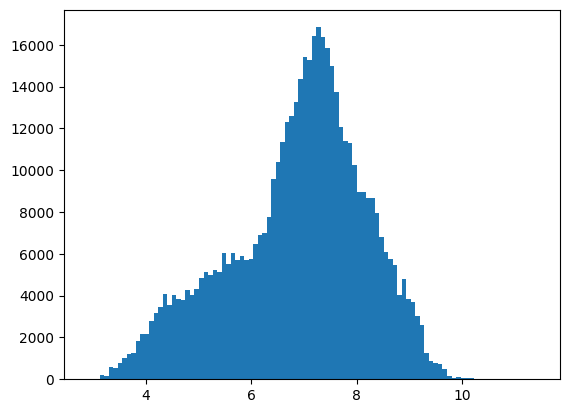

In [ ]:
# Read results from CSV and analyze
csv = pd.read_csv("duet_opt_results_2.csv")
scores = csv['score']
scores[scores == float('inf')] = np.nan  # remove infinite scores
times = csv['time']
times[times > 0.5] = np.nan  # remove massive time outliers
plt.hist(scores, bins=100)
# Best score and total evaluations
np.argmin(scores), len(scores)

In [ ]:
# Make a copy that replaces NaNs with a large value for sorting
scores_x = scores.copy()
scores_x[np.isnan(scores_x)] = 100
np.argsort(scores_x)

0         417603
1         416451
2         328899
3         502851
4         415299
           ...  
518395     87024
518396     87026
518397     87028
518398     87032
518399    248038
Name: score, Length: 518400, dtype: int64

In [ ]:
# Print out the best 20 parameter sets
for i in np.argsort(scores_x)[:20]:
    print(f"{scores[i]:.2f} {times[i]:.3f} {param_grid[i]}")

IndexError: ParameterGrid index out of range

In [ ]:
# Display visual results for a parameter set
param_i = 417603  # np.argsort(scores_x)[0]
for i in range(len(data)):
    plt.figure()
    print(display_params(data[i], param_grid[param_i]))

IndexError: ParameterGrid index out of range

<Figure size 640x480 with 0 Axes>

ValueError: 'c' argument has 8 elements, which is inconsistent with 'x' and 'y' with size 518400.

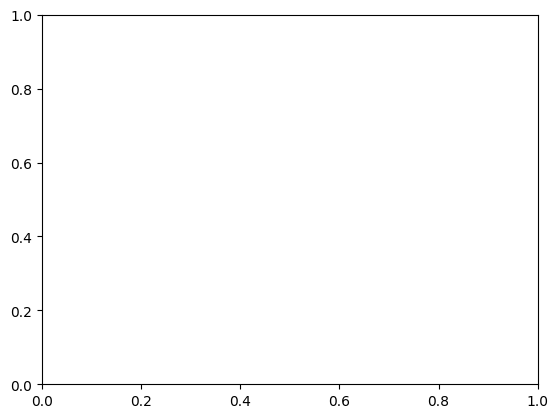

In [36]:
param_grid = ParameterGrid(grid)
# bandwidth_alphas = [x["bandwidth"] if isinstance(x["bandwidth"], float) else x["bandwidth"][0] for x in param_grid][:len(scores)]
# bandwidth_deltas = [x["bandwidth"] if isinstance(x["bandwidth"], float) else x["bandwidth"][1] for x in param_grid][:len(scores)]
# values = np.array([bandwidth_alphas for x in param_grid][:len(scores)])
#values = np.array(bandwidth_deltas[:len(scores)])
#delta_smoothing_value_map = {(1, 1): 1, (3, 1): 2, (3, 3): 3}
#values = np.array([delta_smoothing_value_map[x["delta_smoothing"]] for x in param_grid][:len(scores)])
values = np.array([x["oversample"] for x in param_grid][:len(scores)])
plt.scatter(scores, times, alpha=0.2, s=2, c=values)
plt.colorbar()
plt.xlabel("Score")
plt.ylabel("Time (s)")
plt.ylim(0, 0.2)
for v in np.unique(values):
    s = scores[values == v]
    t = times[values == v]
    print(f"{v}\t{np.min(s):.2f} {np.max(s):.2f} {np.nanmedian(s):.2f} {np.mean(s):.2f} {np.std(s):.2f}    {np.min(t):.2f} {np.max(t):.2f} {np.nanmedian(t):.2f} {np.mean(t):.2f} {np.std(t):.2f}")

In [250]:
grid

{'audio_length': [64, 80, 96],
 'window': [128, 256],
 'oversample': [1, 3],
 'threshold': [0.25, 0.35, 0.5, 0.75],
 'bandwidth': [0.1,
  0.2,
  0.25,
  0.3,
  0.4,
  (0.1, 0.2),
  (0.1, 0.25),
  (0.1, 0.3),
  (0.1, 0.4),
  (0.2, 0.1),
  (0.2, 0.25),
  (0.2, 0.3),
  (0.2, 0.4),
  (0.25, 0.1),
  (0.25, 0.2),
  (0.25, 0.3),
  (0.25, 0.4),
  (0.3, 0.1),
  (0.3, 0.2),
  (0.3, 0.25),
  (0.3, 0.4),
  (0.4, 0.1),
  (0.4, 0.2),
  (0.4, 0.25),
  (0.4, 0.3)],
 'alpha_max': [1.5],
 'delta_max': [8.5],
 'seed_count': [20, 25, 35],
 'min_bin_count': [5, 10],
 'convergence_tol': [0.2, 0.25, 0.3],
 'alpha_op': ['symmetric', 'log'],
 'big_delay': ['diff'],
 'delta_smoothing': [(3, 1), (3, 3), (5, 1), (5, 3)],
 'delta_smoothing_mode': ['mean', 'median', 'gaussian']}

audio_length:
    doesn't seem to have any on time or score...? is it being used?
window:
    256 has the best, but 128 is also very good; 256 is slightly faster; 128 and 256 are quite good; 512 is worse
oversample:
    3 is always 3x slower than 1 and has significantly worse scores
threshold:
    higher thresholds are the fastest and have slightly better scores
bandwidth-alpha:
    bigger is faster; smaller produces smaller scores (although 0.1 is too small, 0.2 or 0.3 seem best)
bandwidth-delta:
    0.1-0.3 seem best; bigger is actually slower here
seed_count:
    lower seed counts are much faster, and are slightly better seems good; somewhere between 25 and 50 seems to be a good tradeoff
min_bin_count:
    between 1 and 5, possibly 5 is a bit better; should expand range
convergence_tol:
    barely any effect on score or time (between 0.05, 0.1, and 0.25)
big_delay:
    'diff' is definitely better (although not exclusively), even if it takes a bit longer
delta_smoothing:
    (1, 1) is worst, (3, 1) is best and doesn't take much longer, (3, 3) is in between in quality but takes longer
delta_smoothing_mode:
    'mean' is slightly worse but faster than 'median'
